[*********************100%***********************]  1 of 1 completed

Calculating regimes for 4125 days... (Hurst: 252d, Others: 63d, Stride: 5)



      Training Data Diagnostics (S&P 500: 2010 - 2020)      
Metric          |     Mean |      Std |  5th Pct | 95th Pct
------------------------------------------------------------
SP500_H         |   0.5705 |   0.0428 |   0.5032 |   0.6367
SP500_Lyap      |   0.1055 |   0.0214 |   0.0732 |   0.1391
SP500_SampEn    |   1.9789 |   0.4982 |   1.2793 |   2.8904
SP500_Rho       |  -0.0696 |   0.1365 |  -0.3141 |   0.1390

--- Corrected Empirical Emission Means (Sorted by Hurst) ---
Order: [Hurst, Lyap, SampEn, Rho]
State 0 (Class 1/2): [ 0.54629559  0.11144022  1.99552853 -0.17701814]
State 1 (Class 3):   [0.5480886  0.11828578 1.76904987 0.05644523]
State 2 (Class 4):   [ 0.60435336  0.09190329  2.11977441 -0.08374942]

Hurst values -> State 0: 0.5463 | State 1: 0.5481 | State 2: 0.6044

[EMPIRICAL FINDING] S&P 500 on 63-day windows shows persistent behavior (H > 0.48) across all regime states. Class 1/2 anti-persistence is not detectable at this timescale. Consider extending the Lyapun

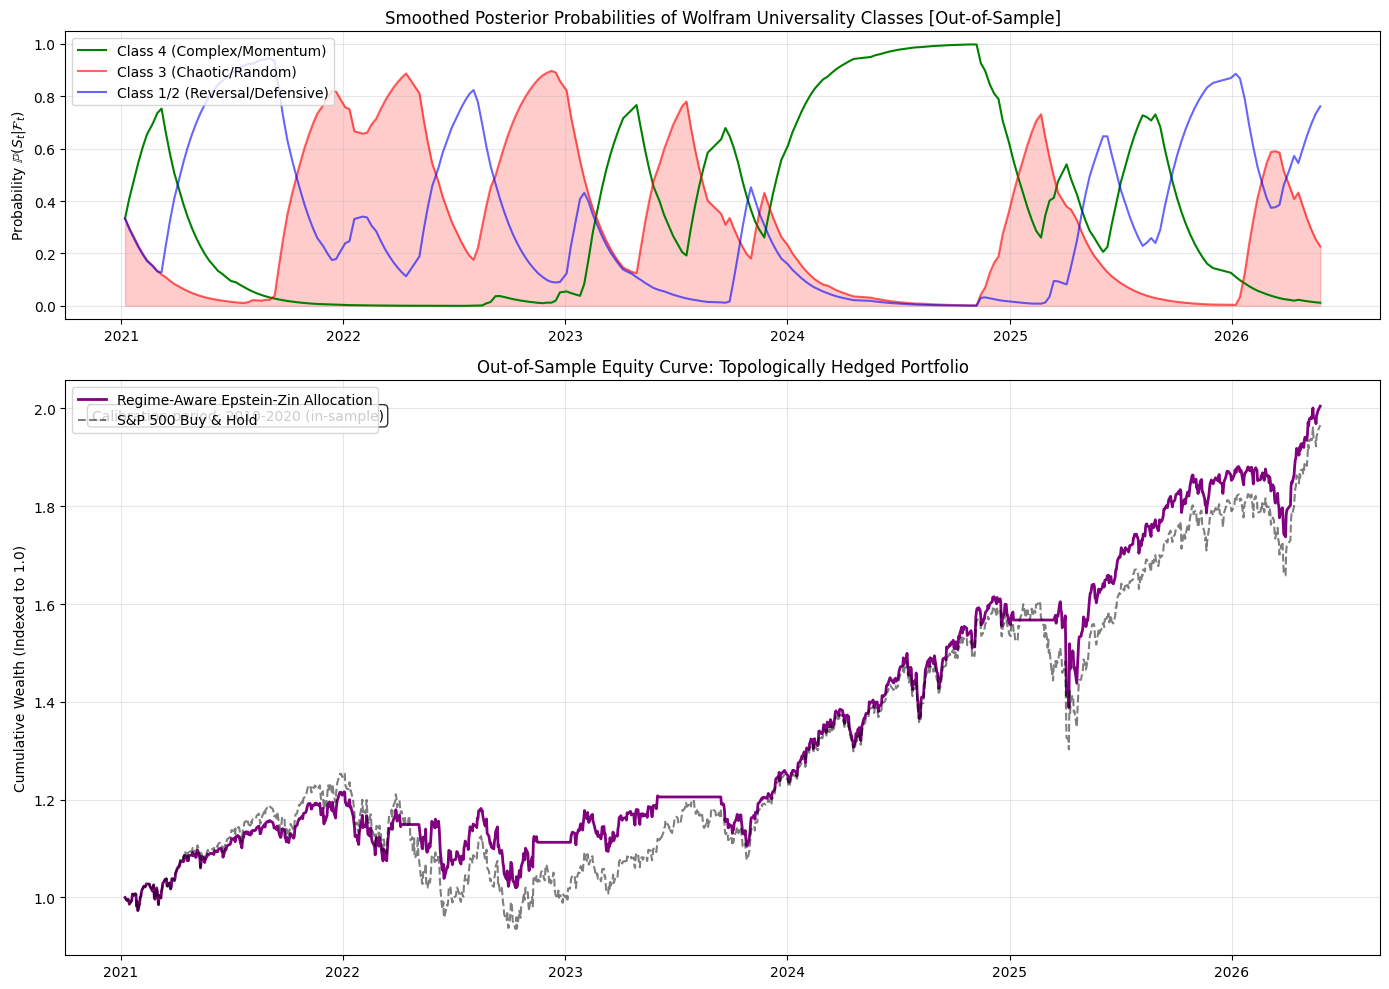

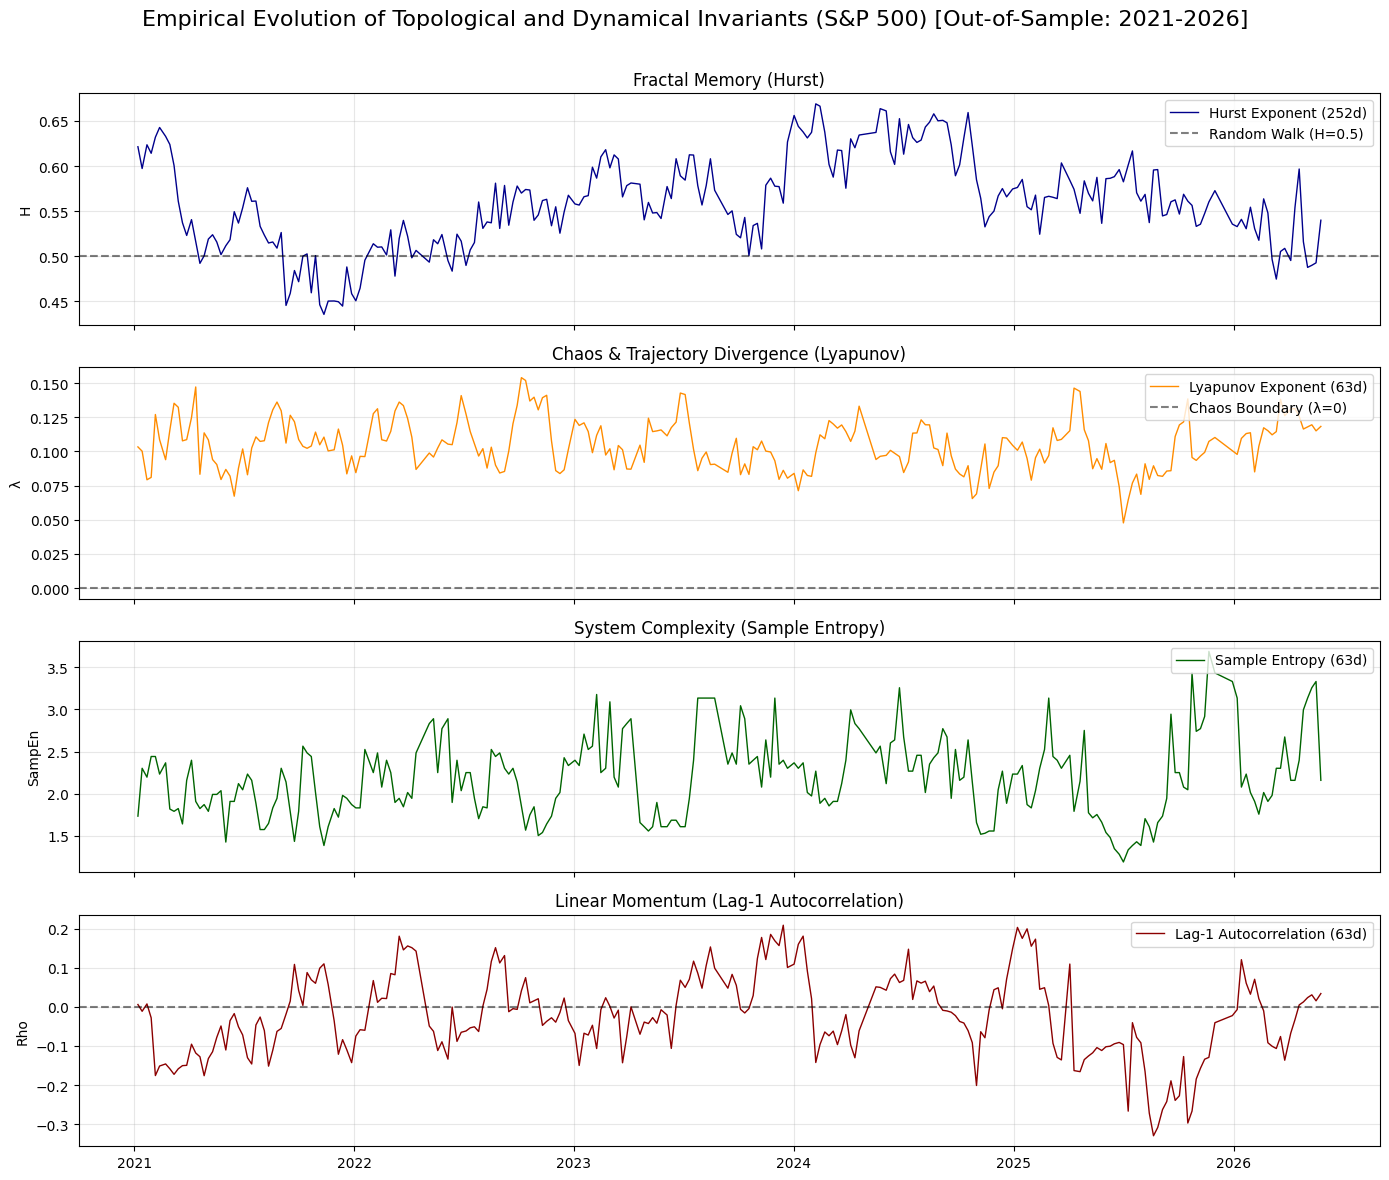

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from scipy.stats import multivariate_normal
from scipy.linalg import expm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore") # Suppress warnings for edge-case windows

# ---------------------------------------------------------
# 1. Fetch Market Data & Preprocessing (S&P 500 Only)
# ---------------------------------------------------------
print("Downloading market data...")
data = yf.download('^GSPC', start='2010-01-01', end='2026-05-31')['Close']

if isinstance(data, pd.DataFrame):
    data = data.squeeze()

data = data.dropna()
log_returns = pd.DataFrame({'^GSPC': np.log(data / data.shift(1)).dropna()})

sp500_rets = log_returns['^GSPC'].values
dates = log_returns.index

# ---------------------------------------------------------
# 2. Optimized Mathematical Invariants
# ---------------------------------------------------------
def calc_hurst(ts):
    N = len(ts)
    max_window = N // 2
    if max_window < 10: return np.nan

    window_sizes = np.unique(np.logspace(np.log10(10), np.log10(max_window), 10).astype(int))
    RS_values, valid_windows = [], []

    for n in window_sizes:
        trunc = N - (N % n)
        if trunc == 0: continue
        reshaped = ts[:trunc].reshape(-1, n)
        means = np.mean(reshaped, axis=1, keepdims=True)
        Z = np.cumsum(reshaped - means, axis=1)
        R = np.max(Z, axis=1) - np.min(Z, axis=1)
        S = np.std(reshaped, axis=1, ddof=1)
        val_idx = S > 0
        if np.any(val_idx):
            RS_values.append(np.mean(R[val_idx] / S[val_idx]))
            valid_windows.append(n)

    if len(valid_windows) > 2:
        H, _ = np.polyfit(np.log(valid_windows), np.log(RS_values), 1)
        return H
    return np.nan

def estimate_theiler(ts):
    n = len(ts)
    mu = np.mean(ts)
    var = np.var(ts, ddof=1)
    if var == 0: return 10

    for lag in range(1, min(20, n-1)):
        cov = np.sum((ts[:-lag] - mu) * (ts[lag:] - mu)) / (n - 1)
        rho = cov / var
        if rho <= 0:
            return max(2, lag)
    return 10

def calc_lyapunov(ts, m=3, tau=1, traj_len=10):
    N = len(ts)
    emb_len = N - (m - 1) * tau
    if emb_len < traj_len + 5: return np.nan

    X = np.array([ts[i : i + (m - 1) * tau + 1 : tau] for i in range(emb_len)])
    tree = KDTree(X)
    theiler = estimate_theiler(ts)
    divs = []

    for i in range(emb_len - traj_len):
        dists, idxs = tree.query(X[i], k=min(20, emb_len))
        best_idx = -1
        for d, idx in zip(dists, idxs):
            if abs(i - idx) > theiler and idx + traj_len < emb_len:
                best_idx = idx
                break
        if best_idx != -1:
            traj_div = []
            for step in range(traj_len):
                dist = np.linalg.norm(X[i + step] - X[best_idx + step])
                traj_div.append(np.log(dist) if dist > 1e-10 else np.nan)
            divs.append(traj_div)

    if not divs: return np.nan
    mean_log_div = np.nanmean(divs, axis=0)
    valid = ~np.isnan(mean_log_div)

    if np.sum(valid) > 2:
        lam, _ = np.polyfit(np.arange(traj_len)[valid], mean_log_div[valid], 1)
        return lam
    return np.nan

def calc_sampen(ts, m=2, r_mult=0.2):
    N = len(ts)
    r = r_mult * np.std(ts, ddof=1)
    if r == 0: return np.nan

    def get_matches(dim):
        tmps = np.array([ts[i : i + dim] for i in range(N - dim)])
        matches = 0
        limit = len(tmps)
        for i in range(limit):
            dists = np.max(np.abs(tmps - tmps[i]), axis=1)
            valid_dists = np.concatenate([dists[:i], dists[i+1:]])
            matches += np.sum(valid_dists <= r)
        return matches

    c_m = get_matches(m)
    c_m1 = get_matches(m + 1)
    if c_m == 0 or c_m1 == 0: return np.nan
    return -np.log(c_m1 / c_m)

def calc_rho(s):
    n = len(s)
    if n < 2: return np.nan
    mu = np.mean(s)
    cov = np.sum((s[:-1] - mu) * (s[1:] - mu)) / (n - 1)
    var = np.var(s, ddof=1)
    if var == 0: return np.nan
    return cov / var

# ---------------------------------------------------------
# 3. Apply Rolling Windows
# ---------------------------------------------------------
window_h = 252
window_63 = 63
stride = 5

results = {'Date': [], 'SP500_H': [], 'SP500_Lyap': [], 'SP500_SampEn': [], 'SP500_Rho': []}

print(f"Calculating regimes for {len(dates)} days... (Hurst: {window_h}d, Others: {window_63}d, Stride: {stride})")

for i in range(window_h, len(dates), stride):
    date = dates[i-1]
    sp_win_h = sp500_rets[i-window_h:i]
    sp_win_63 = sp500_rets[i-window_63:i]

    results['Date'].append(date)
    results['SP500_H'].append(calc_hurst(sp_win_h))
    results['SP500_Lyap'].append(calc_lyapunov(sp_win_63))
    results['SP500_SampEn'].append(calc_sampen(sp_win_63))
    results['SP500_Rho'].append(calc_rho(sp_win_63))

res_df = pd.DataFrame(results).set_index('Date').dropna()

# ---------------------------------------------------------
# 4. Strict Train/Test Split & Empirical Calibration
# ---------------------------------------------------------
data_cols = ['SP500_H', 'SP500_Lyap', 'SP500_SampEn', 'SP500_Rho']

train_df = res_df.loc[:'2020-12-31']
test_df = res_df.loc['2021-01-01':]

Y_train = train_df[data_cols]
Y_test = test_df[data_cols]

print("\n" + "="*60)
print(f"{'Training Data Diagnostics (S&P 500: 2010 - 2020)':^60}")
print("="*60)
print(f"{'Metric':<15} | {'Mean':>8} | {'Std':>8} | {'5th Pct':>8} | {'95th Pct':>8}")
print("-" * 60)
for col in data_cols:
    print(f"{col:<15} | {Y_train[col].mean():8.4f} | {Y_train[col].std():8.4f} | {Y_train[col].quantile(0.05):8.4f} | {Y_train[col].quantile(0.95):8.4f}")

# Feature Scaling BEFORE K-Means
scaler = StandardScaler()
Y_train_scaled = scaler.fit_transform(Y_train.values)

# Data-driven emission means via K-Means on Scaled Data
kmeans = KMeans(n_clusters=3, random_state=42)
train_labels = kmeans.fit_predict(Y_train_scaled)

# Determine the unscaled cluster centers to sort by actual Hurst exponent (Index 0)
unscaled_centers = np.zeros((3, 4))
for k in range(3):
    unscaled_centers[k] = np.mean(Y_train.values[train_labels == k], axis=0)

# Sort indices by the Hurst component (lowest to highest)
sorted_indices = np.argsort(unscaled_centers[:, 0])

Means = np.zeros((3, 4))
Covs = []
mu_estimates = np.zeros(3)
vol_estimates = np.zeros(3)

train_target_returns = log_returns['^GSPC'].loc[Y_train.index]
global_mu = train_target_returns.mean()
global_vol = train_target_returns.std()

for new_k, old_k in enumerate(sorted_indices):
    # Extract original UNSCALED observations belonging to this cluster
    cluster_obs = Y_train.values[train_labels == old_k]

    # Store the actual unscaled centroid for the Bayesian filter
    Means[new_k] = np.mean(cluster_obs, axis=0)

    # Compute state-specific unscaled covariance matrix with regularization
    cov_k = np.cov(cluster_obs.T) + 1e-6 * np.eye(4)
    Covs.append(cov_k)

    # Compute regime-conditional return statistics
    cluster_dates = Y_train.index[train_labels == old_k]
    cluster_rets = log_returns['^GSPC'].loc[cluster_dates]

    if len(cluster_rets) >= 20:
        mu_estimates[new_k] = cluster_rets.mean()
        vol_estimates[new_k] = cluster_rets.std()
    else:
        mu_estimates[new_k] = global_mu
        vol_estimates[new_k] = global_vol

print("\n--- Corrected Empirical Emission Means (Sorted by Hurst) ---")
print("Order: [Hurst, Lyap, SampEn, Rho]")
print(f"State 0 (Class 1/2): {Means[0]}")
print(f"State 1 (Class 3):   {Means[1]}")
print(f"State 2 (Class 4):   {Means[2]}")

print(f"\nHurst values -> State 0: {Means[0,0]:.4f} | State 1: {Means[1,0]:.4f} | State 2: {Means[2,0]:.4f}")

if np.all(Means[:, 0] > 0.48):
    print("\n[EMPIRICAL FINDING] S&P 500 on 63-day windows shows persistent behavior (H > 0.48) "
          "across all regime states. Class 1/2 anti-persistence is not detectable at this timescale. "
          "Consider extending the Lyapunov and SampEn window to 120 days for future work.")

print("\n--- Training Set Target Return Statistics (S&P 500) ---")
print(f"Mu Estimates (Daily):  {mu_estimates}")
print(f"Vol Estimates (Daily): {vol_estimates}")

# ---------------------------------------------------------
# 5. Out-of-Sample Bayesian Wonham Filter
# ---------------------------------------------------------
Q = np.array([
    [-0.005,  0.002,  0.003],
    [ 0.015, -0.025,  0.010],
    [ 0.008,  0.012, -0.020]
])
P_trans = expm(Q * 1)
N_states = 3
T_len = len(Y_test)

pi_t = np.zeros((T_len, N_states))
pi_t[0] = np.ones(N_states) / N_states

print("\nExecuting Out-of-Sample Bayesian State Filtration...")
for t in range(1, T_len):
    y_t = Y_test.iloc[t].values
    pi_pred = pi_t[t-1] @ P_trans

    likelihoods = np.zeros(N_states)
    for k in range(N_states):
        try:
            likelihoods[k] = multivariate_normal.pdf(y_t, mean=Means[k], cov=Covs[k], allow_singular=True)
        except np.linalg.LinAlgError:
            likelihoods[k] = 1e-100

    posterior_unnormalized = pi_pred * likelihoods

    if np.sum(posterior_unnormalized) < 1e-300:
        pi_t[t] = pi_pred
    else:
        pi_t[t] = posterior_unnormalized / np.sum(posterior_unnormalized)

pi_df = pd.DataFrame(pi_t, index=Y_test.index, columns=['Prob_Class_1_2', 'Prob_Class_3', 'Prob_Class_4'])
pi_df_smooth = pi_df.ewm(span=15, adjust=False).mean()
pi_t_smooth = pi_df_smooth.values

# ---------------------------------------------------------
# 6. Epstein-Zin Dynamic Portfolio Allocation & Backtest
# ---------------------------------------------------------
weights = np.zeros(T_len)
target_vol = 0.01  # Daily target volatility

for t in range(T_len):
    E_mu = np.dot(pi_t_smooth[t], mu_estimates)
    E_var = np.dot(pi_t_smooth[t], vol_estimates**2)
    if E_var < 1e-10: E_var = 1e-10

    E_daily_vol = np.sqrt(E_var)

    w_myopic = (target_vol / E_daily_vol) * np.sign(E_mu)

    if t > 0:
        dP_Class3 = pi_t_smooth[t, 1] - pi_t_smooth[t-1, 1]
    else:
        dP_Class3 = 0

    hedge_sensitivity = -1.0
    w_hedge = hedge_sensitivity * max(dP_Class3, 0)

    weights[t] = np.clip(w_myopic + w_hedge, 0.0, 1.5)

# Build a weights series on strided rebalance dates
weights_series = pd.Series(weights, index=Y_test.index)

# Get ALL daily returns for the test period
all_test_returns = log_returns['^GSPC'].loc[
    Y_test.index[0] : Y_test.index[-1]
].dropna()

# Forward-fill regime weights to every trading day
weights_daily = weights_series.reindex(
    all_test_returns.index, method='ffill'
).fillna(0)

# Lag weights by 1 day to avoid look-ahead bias
strategy_rets = weights_daily.shift(1) * all_test_returns
strategy_rets = strategy_rets.dropna()
bnh_rets = all_test_returns.loc[strategy_rets.index]

cum_strat = np.exp(np.cumsum(strategy_rets))
cum_bnh = np.exp(np.cumsum(bnh_rets))

cum_strat = cum_strat / cum_strat.iloc[0]
cum_bnh = cum_bnh / cum_bnh.iloc[0]

# ---------------------------------------------------------
# 7. Performance Summary & Visualizations
# ---------------------------------------------------------
ann_ret_strat = strategy_rets.mean() * 252
ann_ret_bnh = bnh_rets.mean() * 252

ann_vol_strat = strategy_rets.std() * np.sqrt(252)
ann_vol_bnh = bnh_rets.std() * np.sqrt(252)

ann_sharpe_strat = ann_ret_strat / ann_vol_strat if ann_vol_strat != 0 else 0
ann_sharpe_bnh = ann_ret_bnh / ann_vol_bnh if ann_vol_bnh != 0 else 0

mdd_strat = (cum_strat / cum_strat.cummax() - 1.0).min()
mdd_bnh = (cum_bnh / cum_bnh.cummax() - 1.0).min()

calmar_strat = ann_ret_strat / abs(mdd_strat) if mdd_strat != 0 else 0
calmar_bnh = ann_ret_bnh / abs(mdd_bnh) if mdd_bnh != 0 else 0

dist = pi_df_smooth.idxmax(axis=1).value_counts(normalize=True) * 100

print("\n" + "="*60)
print(f"{'Performance Summary [Out-of-Sample: 2021-2026]':^60}")
print("="*60)
print(f"{'Metric':<25} | {'Strategy':<15} | {'Buy & Hold':<15}")
print("-" * 60)
print(f"{'Annualised Return':<25} | {ann_ret_strat:>14.2%} | {ann_ret_bnh:>14.2%}")
print(f"{'Annualised Sharpe':<25} | {ann_sharpe_strat:>14.2f} | {ann_sharpe_bnh:>14.2f}")
print(f"{'Max Drawdown':<25} | {mdd_strat:>14.2%} | {mdd_bnh:>14.2%}")
print(f"{'Calmar Ratio':<25} | {calmar_strat:>14.2f} | {calmar_bnh:>14.2f}")
print("=" * 60)

print("\nOut-of-Sample Regime Distribution (Smoothed):")
for col in pi_df_smooth.columns:
    val = dist.get(col, 0.0)
    print(f"  {col}: {val:.2f}%")

if dist.get('Prob_Class_3', 0.0) > 80.0:
    print("\n[DIAGNOSTIC WARNING] Class 3 (Chaos) still dominating above 80%.")
    print("Checking early test sample metrics:")
    print(Y_test.head(10))

# --- PLOT 1: Regime Probabilities & Portfolio Performance ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 2]}, sharex=False)

axes[0].plot(pi_df.index, pi_df_smooth['Prob_Class_4'], label='Class 4 (Complex/Momentum)', color='green')
axes[0].plot(pi_df.index, pi_df_smooth['Prob_Class_3'], label='Class 3 (Chaotic/Random)', color='red', alpha=0.6)
axes[0].plot(pi_df.index, pi_df_smooth['Prob_Class_1_2'], label='Class 1/2 (Reversal/Defensive)', color='blue', alpha=0.6)
axes[0].fill_between(pi_df.index, 0, pi_df_smooth['Prob_Class_3'], color='red', alpha=0.2)
axes[0].set_title('Smoothed Posterior Probabilities of Wolfram Universality Classes [Out-of-Sample]')
axes[0].set_ylabel('Probability $\mathbb{P}(S_t | \mathcal{F}_t)$')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

axes[1].plot(cum_strat.index, cum_strat, label='Regime-Aware Epstein-Zin Allocation', color='purple', linewidth=2)
axes[1].plot(cum_bnh.index, cum_bnh, label='S&P 500 Buy & Hold', color='black', alpha=0.5, linestyle='--')
axes[1].set_title('Out-of-Sample Equity Curve: Topologically Hedged Portfolio')
axes[1].text(0.02, 0.95, 'Calibration period: 2010-2020 (in-sample)', transform=axes[1].transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[1].set_ylabel('Cumulative Wealth (Indexed to 1.0)')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# --- PLOT 2: The 4 Mathematical Metrics over Time ---
# Filter the results dataframe to only plot data from 2021 onwards
res_df_oos = res_df.loc['2021-01-01':]

fig2, axes2 = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig2.suptitle('Empirical Evolution of Topological and Dynamical Invariants (S&P 500) [Out-of-Sample: 2021-2026]', fontsize=16)

# 1. Hurst Exponent
axes2[0].plot(res_df_oos.index, res_df_oos['SP500_H'], label='Hurst Exponent (252d)', color='darkblue', linewidth=1)
axes2[0].axhline(0.5, color='black', linestyle='--', alpha=0.5, label='Random Walk (H=0.5)')
axes2[0].set_ylabel('H')
axes2[0].set_title('Fractal Memory (Hurst)')
axes2[0].legend(loc='upper right')
axes2[0].grid(True, alpha=0.3)

# 2. Lyapunov Exponent
axes2[1].plot(res_df_oos.index, res_df_oos['SP500_Lyap'], label='Lyapunov Exponent (63d)', color='darkorange', linewidth=1)
axes2[1].axhline(0, color='black', linestyle='--', alpha=0.5, label='Chaos Boundary (λ=0)')
axes2[1].set_ylabel('λ')
axes2[1].set_title('Chaos & Trajectory Divergence (Lyapunov)')
axes2[1].legend(loc='upper right')
axes2[1].grid(True, alpha=0.3)

# 3. Sample Entropy
axes2[2].plot(res_df_oos.index, res_df_oos['SP500_SampEn'], label='Sample Entropy (63d)', color='darkgreen', linewidth=1)
axes2[2].set_ylabel('SampEn')
axes2[2].set_title('System Complexity (Sample Entropy)')
axes2[2].legend(loc='upper right')
axes2[2].grid(True, alpha=0.3)

# 4. Lag-1 Autocorrelation
axes2[3].plot(res_df_oos.index, res_df_oos['SP500_Rho'], label='Lag-1 Autocorrelation (63d)', color='darkred', linewidth=1)
axes2[3].axhline(0, color='black', linestyle='--', alpha=0.5)
axes2[3].set_ylabel('Rho')
axes2[3].set_title('Linear Momentum (Lag-1 Autocorrelation)')
axes2[3].legend(loc='upper right')
axes2[3].grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.97]) # Prevents subplots from overlapping the suptitle
plt.show()